# Fig S11. trial

In [1]:
from util import fisherztrans,stat_m_e,pair_test,sig,color_inv_alpha,corr_batch_nan
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from faceprf_figure_function import set_figure,set_ax,myviolinplot_ind,myviolinplot_pair,myviolinplot_multi
import pingouin
import statsmodels.formula.api as smf

# setting
nsubj = 8
npos = 16
task = ['Digit Task','Face Task']
roi_labels = ['V1','V2','V3','hV4','IOG','pFus','mFus']
nroi = len(roi_labels)
ntask = len(task)

# data path
data_path = "../data/"

# load data
data = np.load(f'{data_path}/trialest.npz')
mean0_all = data['mean0_all']
mean1_all = data['mean1_all']
var0_all = data['var0_all']
var1_all = data['var1_all']
corr0_all = data['corr0_all']
corr1_all = data['corr1_all']
ntrial_list = data['ntrial_list'] # 10, 20, 40, 80, 100, 200, 400

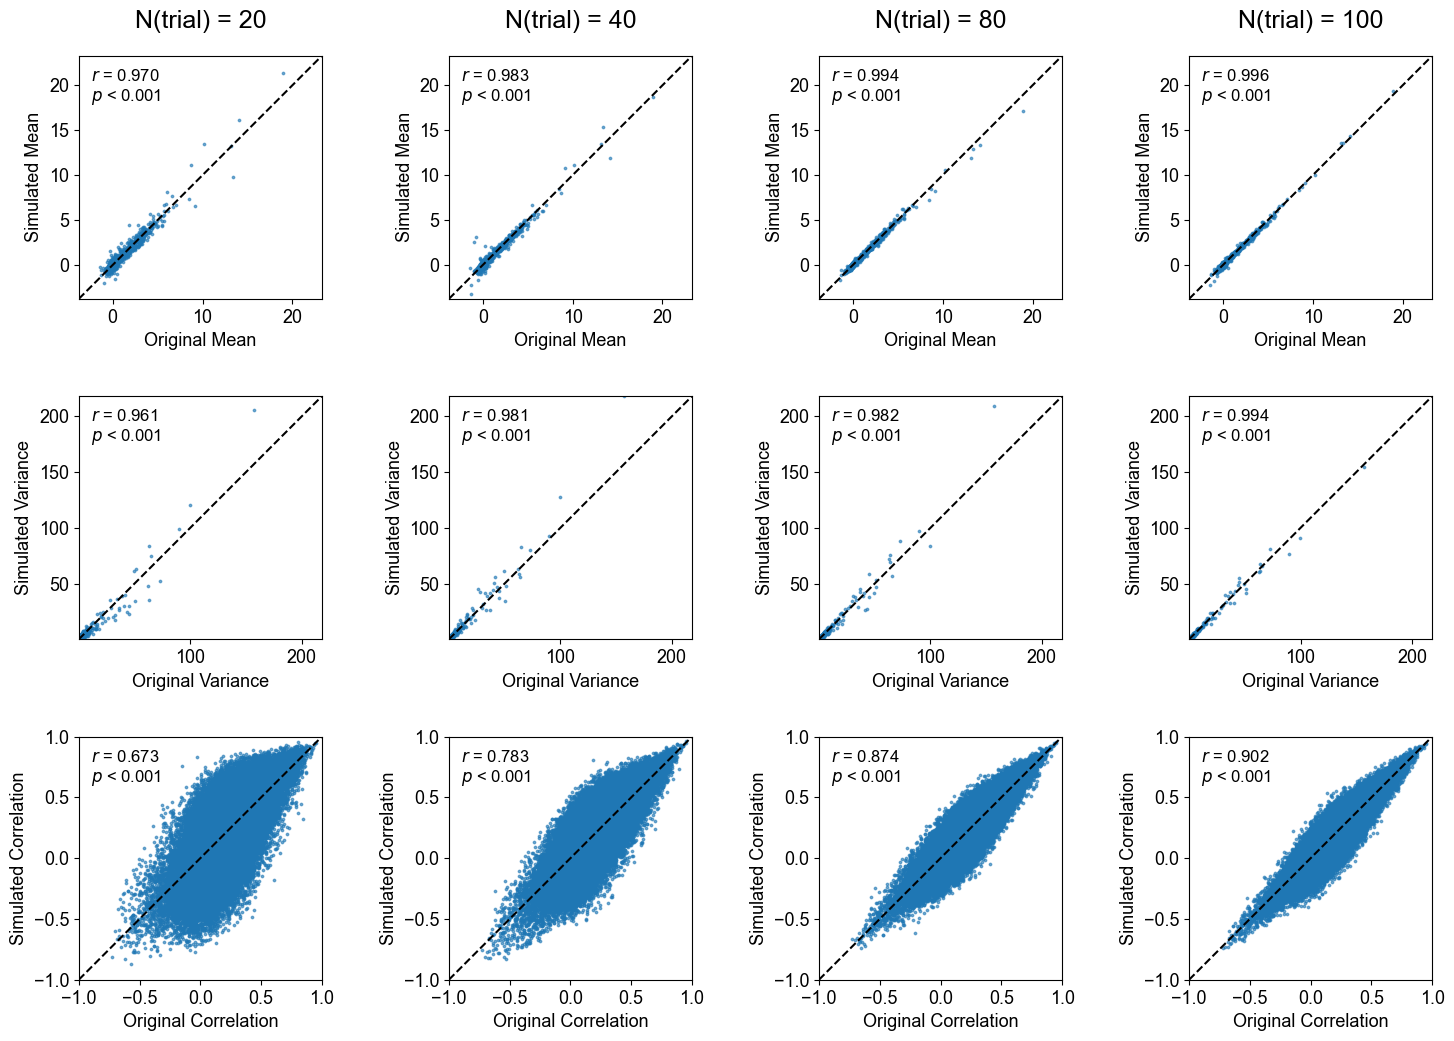

In [2]:
from scipy.stats import pearsonr


ntrial_sel = [1, 2, 3, 4]

set_figure()

fig, axes = plt.subplots(
    3, len(ntrial_sel),
    figsize=(18, 12),
    gridspec_kw={'wspace': 0.3, 'hspace': 0.4}
)

def scatter_with_stats(ax, x, y, xlabel, ylabel, lims=None):
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=3, alpha=0.6, rasterized=True)

    if len(x) > 1:
        r, p = pearsonr(x, y)
        r2 = r ** 2

        if p < 1e-3:
            p_text = "$p$ < 0.001"
        else:
            p_text = f"$p$ = {p:.3f}"

        stat_text = f"$r$ = {r:.3f}\n{p_text}"
    else:
        stat_text = "N < 2"

    if lims is None:
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]

    ax.plot(lims, lims, 'k--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    ax.text(
        0.05, 0.95,
        stat_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=12
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


# ============================================
for j, idx in enumerate(ntrial_sel):

    # -------- Row 0: Mean --------
    x = mean0_all[idx, :]
    y = mean1_all[idx, :]
    lims = [
        min(mean0_all.min(), mean1_all.min()),
        max(mean0_all.max(), mean1_all.max())
    ]

    scatter_with_stats(
        axes[0, j],
        x, y,
        xlabel="Original Mean",
        ylabel="Simulated Mean",
        lims=lims
    )

    axes[0, j].set_title(
        f"N(trial) = {ntrial_list[idx]}",
        fontsize=18,
        pad=20
    )

    # -------- Row 1: Variance --------
    x = var0_all[idx, :]
    y = var1_all[idx, :]
    lims = [
        min(var0_all.min(), var1_all.min()),
        max(var0_all.max(), var1_all.max())
    ]

    scatter_with_stats(
        axes[1, j],
        x, y,
        xlabel="Original Variance",
        ylabel="Simulated Variance",
        lims=lims
    )

    # -------- Row 2: Correlation --------
    x = corr0_all[idx, :]
    y = corr1_all[idx, :]
    lims = [-1, 1]

    scatter_with_stats(
        axes[2, j],
        x, y,
        xlabel="Original Correlation",
        ylabel="Simulated Correlation",
        lims=lims
    )


fig.savefig("figS11-trialest.pdf", dpi=300, bbox_inches="tight")


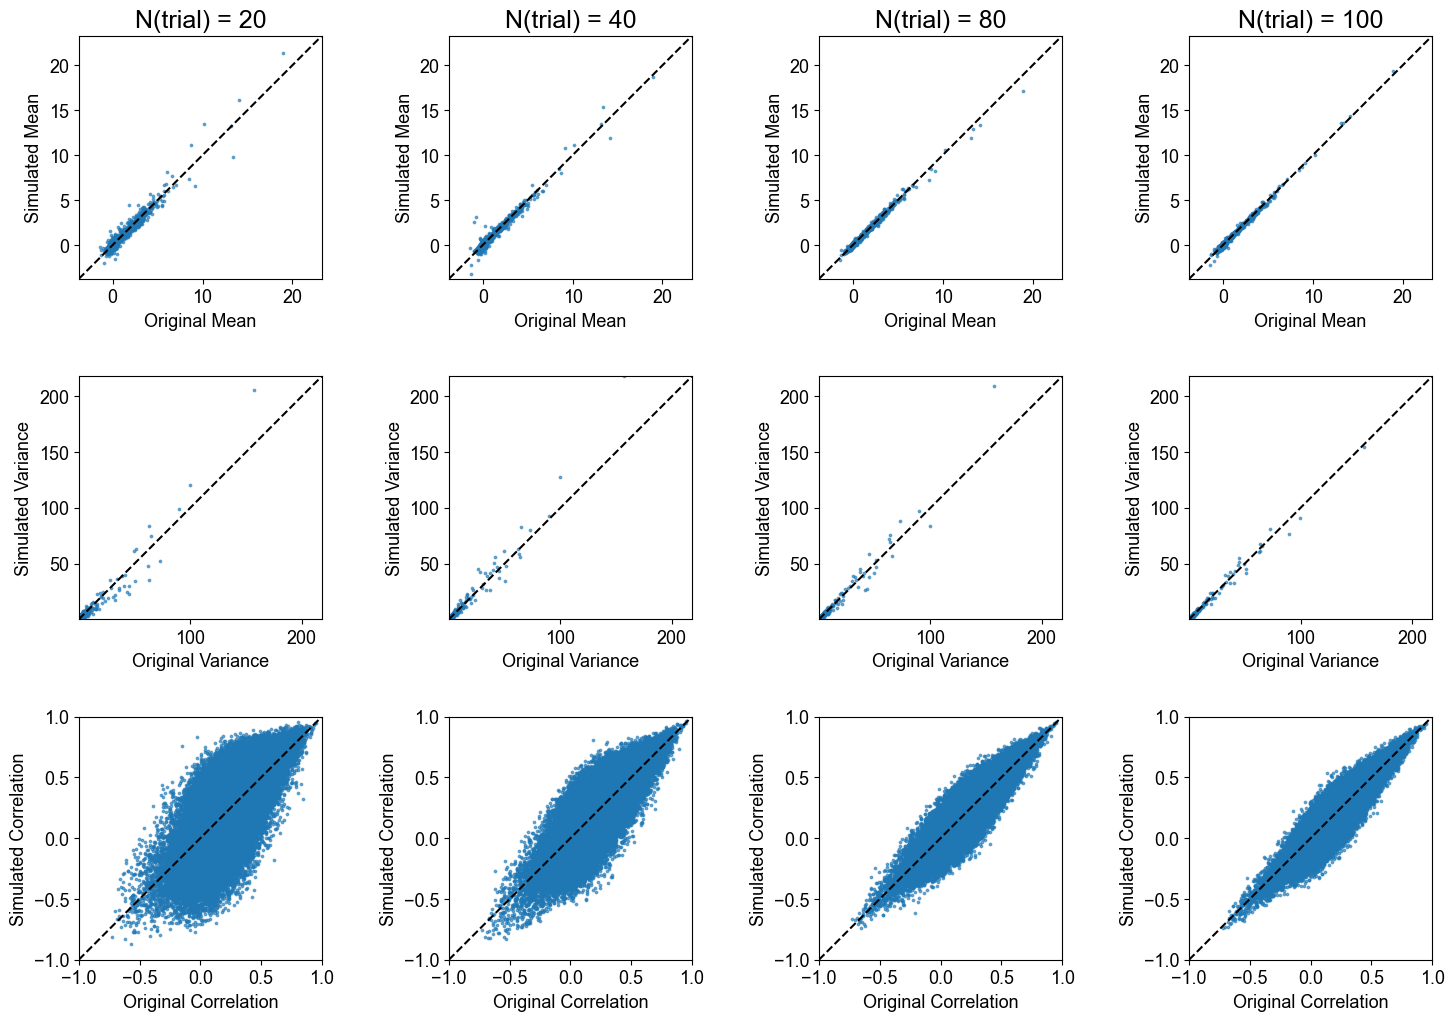

In [3]:
ntrial_sel = [1,2,3,4]

set_figure()
fig, axes = plt.subplots(
    3, len(ntrial_sel),
    figsize=(18, 12),
    gridspec_kw={'wspace': 0.3, 'hspace': 0.4}
)

for j, idx in enumerate(ntrial_sel):

    # =========================
    # Row 0 — Mean
    # =========================
    ax = axes[0, j]

    ax.scatter(mean0_all[idx,:], mean1_all[idx,:],
               s=3, alpha=0.6, rasterized=True)

    lims = [
        min(mean0_all.min(), mean1_all.min()),
        max(mean0_all.max(), mean1_all.max())
    ]
    ax.plot(lims, lims, 'k--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    ax.set_ylabel("Simulated Mean")
    ax.set_xlabel("Original Mean")

    ax.set_title(f"N(trial) = {ntrial_list[idx]}", fontsize=18)


    # =========================
    # Row 1 — Variance
    # =========================
    ax = axes[1, j]

    ax.scatter(var0_all[idx,:], var1_all[idx,:],
               s=3, alpha=0.6, rasterized=True)

    lims = [
        min(var0_all.min(), var1_all.min()),
        max(var0_all.max(), var1_all.max())
    ]
    ax.plot(lims, lims, 'k--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    ax.set_ylabel("Simulated Variance")
    ax.set_xlabel("Original Variance")


    # =========================
    # Row 2 — Correlation
    # =========================
    ax = axes[2, j]

    ax.scatter(corr0_all[idx,:], corr1_all[idx,:],
               s=3, alpha=0.6, rasterized=True)

    lims = [-1, 1]
    ax.plot(lims, lims, 'k--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    ax.set_ylabel("Simulated Correlation")
    ax.set_xlabel("Original Correlation")


fig.savefig('figS11-trialest.pdf')


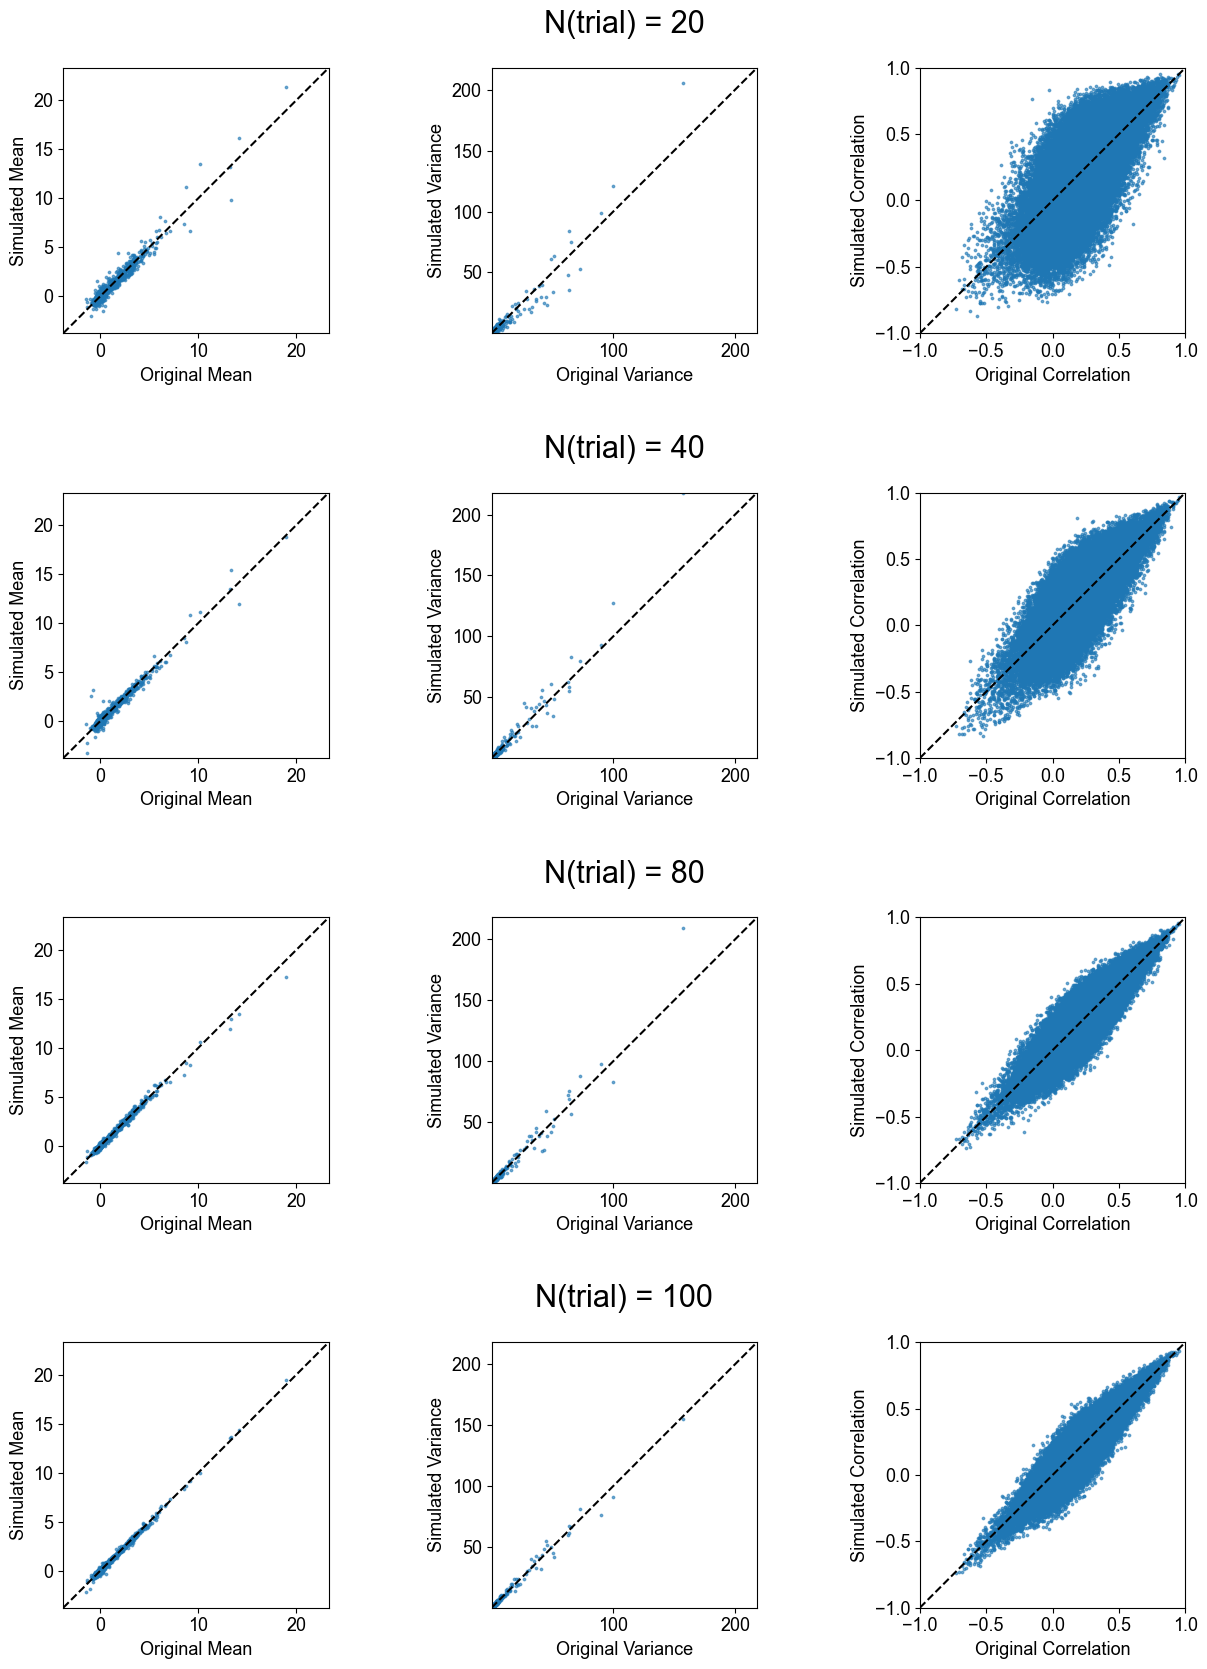

In [ ]:
ntrial_sel = [1,2,3,4]

set_figure()
fig,axes = plt.subplots(len(ntrial_sel),3,figsize=(15,20),gridspec_kw={'wspace': 0.4,'hspace':0.6})
for i in range(len(ntrial_sel)):
    # mean
    ax = axes[i,0]
    idx = ntrial_sel[i]

    ax.scatter(mean0_all[idx,:],mean1_all[idx,:],s=3,alpha=0.6, rasterized=True)
    ax.set_xlabel("Original Mean")
    ax.set_ylabel("Simulated Mean")
    lims = [min(mean0_all.min(),mean1_all.min()),max(mean0_all.max(),mean1_all.max())]
    ax.plot(lims, lims, 'k--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_aspect('equal', adjustable='box')

    # variance
    ax = axes[i,1]
    idx = ntrial_sel[i]

    ax.scatter(var0_all[idx,:],var1_all[idx,:],s=3,alpha=0.6, rasterized=True)
    ax.set_xlabel("Original Variance")
    ax.set_ylabel("Simulated Variance")
    lims = [min(var0_all.min(),var1_all.min()),max(var0_all.max(),var1_all.max())]
    ax.plot(lims, lims, 'k--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_aspect('equal', adjustable='box')

    # correlation
    ax = axes[i,2]
    idx = ntrial_sel[i]

    ax.scatter(corr0_all[idx,:],corr1_all[idx,:],s=3,alpha=0.6, rasterized=True)
    ax.set_xlabel("Original Correlation")
    ax.set_ylabel("Simulated Correlation")
    lims = [-1,1]
    ax.plot(lims, lims, 'k--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_aspect('equal', adjustable='box')

    axes[i,1].set_title('N(trial) = '+str(ntrial_list[idx]),pad=25,fontsize=22)

fig.savefig('../figures/figS11-trialest.pdf')